# State-space response viewer

Load the FEM system matrices and previously saved state-space responses without rerunning the simulation.

In [1]:
import pickle

import matplotlib.pyplot as plt
import numpy as np

# Load the FEM matrices used by the simulation.
system_data = np.load("owt_XKM.npz")
X = system_data["X"]
M = np.asarray(system_data["M"], dtype=float)
K = np.asarray(system_data["K"], dtype=float)

# Load the state-space outputs saved by State_space_Dynamics.ipynb.
with open("state_space_responses.pkl", "rb") as pickle_file:
    state_space_responses = pickle.load(pickle_file)

print(f"X shape: {X.shape}")
print(f"M shape: {M.shape}")
print(f"K shape: {K.shape}")
print("Response keys:", list(state_space_responses))
for key, value in state_space_responses.items():
    if isinstance(value, np.ndarray):
        print(f"{key} shape: {value.shape}")
    else:
        print(f"{key}: {value}")

X shape: (3, 279)
M shape: (1674, 1674)
K shape: (1674, 1674)
Response keys: ['time', 'sinusoidal_force', 'ship_impact_force', 'z_sine', 'z_ship', 'z_free', 'selected_dofs', 'selected_nodes', 'selected_direction', 'force_node', 'force_dof', 'dt']
time shape: (20001,)
sinusoidal_force shape: (20001,)
ship_impact_force shape: (20001,)
z_sine shape: (4, 20001)
z_ship shape: (4, 20001)
z_free shape: (4, 20001)
selected_dofs shape: (2,)
selected_nodes: [41, 50]
selected_direction: 2
force_node: 50
force_dof: 295
dt: 0.001


In [8]:
time = state_space_responses["time"]
z_sine = state_space_responses["z_sine"]
z_ship = state_space_responses["z_ship"]
z_free = state_space_responses["z_free"]
selected_dofs = state_space_responses["selected_dofs"]
selected_nodes = [41]
selected_direction = state_space_responses["selected_direction"]

n_selected = len(selected_dofs)
time_mask = time <= 20.0
print("Selected nodes:", selected_nodes)
print("Selected DOFs:", selected_dofs)
print("Selected direction:", selected_direction)
print("Number of saved time steps:", len(time))

Selected nodes: [41]
Selected DOFs: [241 295]
Selected direction: 2
Number of saved time steps: 20001


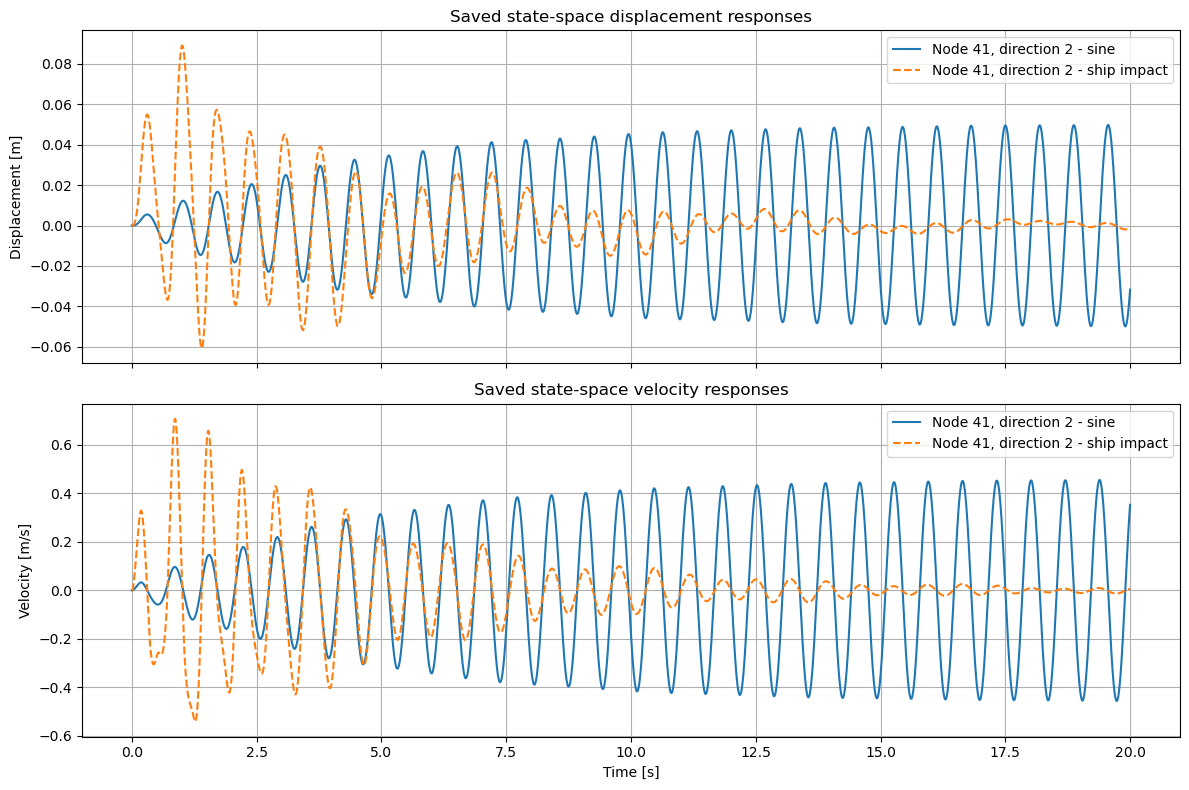

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for i, node in enumerate(selected_nodes):
    label = f"Node {node}, direction {selected_direction}"
    axes[0].plot(
        time[time_mask],
        z_sine[i, time_mask],
        label=f"{label} - sine",
    )
    axes[0].plot(
        time[time_mask],
        z_ship[i, time_mask],
        "--",
        label=f"{label} - ship impact",
    )

    axes[1].plot(
        time[time_mask],
        z_sine[n_selected + i, time_mask],
        label=f"{label} - sine",
    )
    axes[1].plot(
        time[time_mask],
        z_ship[n_selected + i, time_mask],
        "--",
        label=f"{label} - ship impact",
    )
    # also plot the free vibration

axes[0].set_ylabel("Displacement [m]")
axes[0].set_title("Saved state-space displacement responses")
axes[1].set_ylabel("Velocity [m/s]")
axes[1].set_xlabel("Time [s]")
axes[1].set_title("Saved state-space velocity responses")

for ax in axes:
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

In [7]:
# Example: displacement response of the first selected output for the sine load.
first_selected_displacement = z_sine[0, :]
print("First selected displacement shape:", first_selected_displacement.shape)

First selected displacement shape: (20001,)
